# XGBoost Basic

In [6]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns

# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import LabelEncoder
# from sklearn.metrics import accuracy_score, confusion_matrix
# from sklearn.utils.class_weight import compute_sample_weight

# from xgboost import XGBClassifier


# # =========================
# # Load train data
# # =========================
# df = pd.read_csv("train.csv")

# train_ids = df["id"].copy()

# df = df.drop(columns=["id"])

# X = df.drop(columns=["class"]).copy()
# y = df["class"].copy()


# # =========================
# # Encode target
# # =========================
# target_encoder = LabelEncoder()
# y_encoded = target_encoder.fit_transform(y)

# class_names = target_encoder.classes_
# print("Classes:", class_names)


# # =========================
# # Encode categorical features
# # =========================
# cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

# feature_encoders = {}

# for col in cat_cols:
#   encoder = LabelEncoder()

#   X[col] = X[col].astype(str).fillna("Missing")
#   X[col] = encoder.fit_transform(X[col])

#   feature_encoders[col] = encoder


# # =========================
# # Make all columns numeric
# # =========================
# for col in X.columns:
#   X[col] = pd.to_numeric(X[col], errors="coerce")

# train_medians = X.median(numeric_only=True)
# X = X.fillna(train_medians)


# # =========================
# # Train-test split
# # =========================
# X_train, X_val, y_train, y_val = train_test_split(
#   X,
#   y_encoded,
#   test_size=0.2,
#   stratify=y_encoded,
#   random_state=42
# )


# # =========================
# # Class-balanced sample weights
# # =========================
# sample_weights = compute_sample_weight(
#   class_weight="balanced",
#   y=y_train
# )


# # =========================
# # Validation model
# # =========================
# model = XGBClassifier(
#   objective="multi:softprob",
#   num_class=len(class_names),

#   n_estimators=2000,
#   learning_rate=0.03,
#   max_depth=6,
#   min_child_weight=1,

#   subsample=0.8,
#   colsample_bytree=0.8,

#   reg_alpha=0.0,
#   reg_lambda=1.0,

#   tree_method="hist",
#   eval_metric="mlogloss",

#   random_state=42,
#   n_jobs=-1
# )


# model.fit(
#   X_train,
#   y_train,
#   sample_weight=sample_weights,
#   eval_set=[(X_val, y_val)],
#   verbose=False
# )


# # =========================
# # Validation prediction
# # =========================
# y_pred = model.predict(X_val)

# acc = accuracy_score(y_val, y_pred)

# print(f"\nValidation accuracy: {acc:.5f}")


# # =========================
# # Confusion matrix
# # =========================
# cm = confusion_matrix(
#   y_val,
#   y_pred,
#   labels=np.arange(len(class_names))
# )

# cm_df = pd.DataFrame(
#   cm,
#   index=[f"True_{c}" for c in class_names],
#   columns=[f"Pred_{c}" for c in class_names]
# )

# print("\nConfusion matrix:")
# print(cm_df)


# # =========================
# # Confusion matrix percentage
# # =========================
# cm_percent = cm / cm.sum(axis=1, keepdims=True) * 100

# cm_percent_df = pd.DataFrame(
#   cm_percent,
#   index=[f"True_{c}" for c in class_names],
#   columns=[f"Pred_{c}" for c in class_names]
# )

# print("\nConfusion matrix (% by true class):")
# print(cm_percent_df.round(2))


# # =========================
# # Plot confusion matrix: counts
# # =========================
# plt.figure(figsize=(9, 7))

# sns.heatmap(
#   cm_df,
#   annot=True,
#   fmt="d",
#   cmap="Blues",
#   linewidths=0.5,
#   linecolor="white",
#   cbar=True
# )

# plt.title("Confusion Matrix - Counts", fontsize=16, weight="bold")
# plt.xlabel("Predicted class")
# plt.ylabel("True class")
# plt.xticks(rotation=45, ha="right")
# plt.yticks(rotation=0)
# plt.tight_layout()
# plt.show()


# # =========================
# # Plot confusion matrix: row percentage
# # =========================
# plt.figure(figsize=(9, 7))

# sns.heatmap(
#   cm_percent_df,
#   annot=True,
#   fmt=".2f",
#   cmap="Blues",
#   linewidths=0.5,
#   linecolor="white",
#   cbar=True
# )

# plt.title("Confusion Matrix - Percentage by True Class", fontsize=16, weight="bold")
# plt.xlabel("Predicted class")
# plt.ylabel("True class")
# plt.xticks(rotation=45, ha="right")
# plt.yticks(rotation=0)
# plt.tight_layout()
# plt.show()


# # ============================================================
# # Train final model on ALL training data
# # ============================================================
# final_sample_weights = compute_sample_weight(
#   class_weight="balanced",
#   y=y_encoded
# )

# final_model = XGBClassifier(
#   objective="multi:softprob",
#   num_class=len(class_names),

#   n_estimators=2000,
#   learning_rate=0.03,
#   max_depth=6,
#   min_child_weight=1,

#   subsample=0.8,
#   colsample_bytree=0.8,

#   reg_alpha=0.0,
#   reg_lambda=1.0,

#   tree_method="hist",
#   eval_metric="mlogloss",

#   random_state=42,
#   n_jobs=-1
# )

# final_model.fit(
#   X,
#   y_encoded,
#   sample_weight=final_sample_weights,
#   verbose=False
# )


# # ============================================================
# # Load test.csv and preprocess using SAME encoders/medians
# # ============================================================
# test_df = pd.read_csv("test.csv")

# test_ids = test_df["id"].copy()

# X_test_final = test_df.drop(columns=["id"]).copy()


# # Encode categorical columns using train encoders
# for col in cat_cols:
#   if col in X_test_final.columns:
#     X_test_final[col] = X_test_final[col].astype(str).fillna("Missing")

#     known_classes = set(feature_encoders[col].classes_)

#     X_test_final[col] = X_test_final[col].apply(
#       lambda x: x if x in known_classes else "Missing"
#     )

#     # If "Missing" was not present during training, add safe fallback
#     if "Missing" not in feature_encoders[col].classes_:
#       feature_encoders[col].classes_ = np.append(
#         feature_encoders[col].classes_,
#         "Missing"
#       )

#     X_test_final[col] = feature_encoders[col].transform(X_test_final[col])


# # Make numeric
# for col in X_test_final.columns:
#   X_test_final[col] = pd.to_numeric(X_test_final[col], errors="coerce")


# # Align columns exactly with training features
# X_test_final = X_test_final.reindex(columns=X.columns)


# # Fill missing values using train medians
# X_test_final = X_test_final.fillna(train_medians)


# # ============================================================
# # Predict test.csv
# # ============================================================
# test_pred_encoded = final_model.predict(X_test_final)
# test_pred_labels = target_encoder.inverse_transform(test_pred_encoded)


# # ============================================================
# # Save submission
# # ============================================================
# submission = pd.DataFrame({
#   "id": test_ids,
#   "class": test_pred_labels
# })

# submission.to_csv("submission.csv", index=False)

# print("\nSaved submission.csv")
# print(submission.head())

Validation accuracy: 0.96136

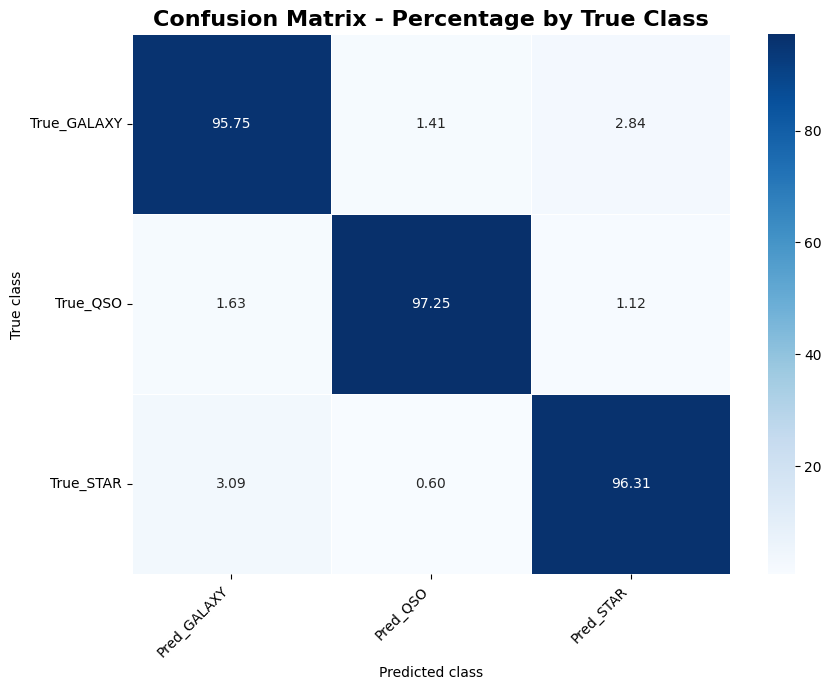

# XGBoost Manually Tune For n_estimators

In [7]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns

# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import LabelEncoder
# from sklearn.metrics import accuracy_score, confusion_matrix
# from sklearn.utils.class_weight import compute_sample_weight

# from xgboost import XGBClassifier


# # =========================
# # Settings
# # =========================
# RANDOM_STATE = 42


# # =========================
# # Load train data
# # =========================
# df = pd.read_csv("train.csv")

# train_ids = df["id"].copy()

# df = df.drop(columns=["id"])

# X = df.drop(columns=["class"]).copy()
# y = df["class"].copy()


# # =========================
# # Encode target
# # =========================
# target_encoder = LabelEncoder()
# y_encoded = target_encoder.fit_transform(y)

# class_names = target_encoder.classes_
# print("Classes:", class_names)


# # =========================
# # Encode categorical features
# # =========================
# cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

# feature_encoders = {}

# for col in cat_cols:
#   encoder = LabelEncoder()

#   X[col] = X[col].astype(str).fillna("Missing")
#   X[col] = encoder.fit_transform(X[col])

#   feature_encoders[col] = encoder


# # =========================
# # Make all columns numeric
# # =========================
# for col in X.columns:
#   X[col] = pd.to_numeric(X[col], errors="coerce")

# train_medians = X.median(numeric_only=True)
# X = X.fillna(train_medians)


# # ============================================================
# # Stratified train-validation split
# # ============================================================
# X_train, X_val, y_train, y_val = train_test_split(
#   X,
#   y_encoded,
#   test_size=0.2,
#   stratify=y_encoded,
#   random_state=RANDOM_STATE
# )

# print("\nSplit sizes:")
# print("X_train:", X_train.shape)
# print("y_train:", y_train.shape)
# print("X_val:", X_val.shape)
# print("y_val:", y_val.shape)


# # =========================
# # Class-balanced sample weights
# # =========================
# sample_weights = compute_sample_weight(
#   class_weight="balanced",
#   y=y_train
# )


# # ============================================================
# # Manual Grid Search for n_estimators
# # Total model trainings = 11
# # ============================================================
# n_estimators_grid = list(range(1000, 3001, 200))

# grid_results = []

# best_acc = -1
# best_n_estimators = None
# best_model = None
# best_cm = None
# best_cm_percent = None

# for n_estimators in n_estimators_grid:
#   print(f"\nTraining n_estimators = {n_estimators}")

#   params = {
#     "objective": "multi:softprob",
#     "num_class": len(class_names),

#     "n_estimators": n_estimators,
#     "learning_rate": 0.03,
#     "max_depth": 6,
#     "min_child_weight": 1,

#     "subsample": 0.8,
#     "colsample_bytree": 0.8,

#     "reg_alpha": 0.0,
#     "reg_lambda": 1.0,

#     "tree_method": "hist",
#     "eval_metric": "mlogloss",

#     "random_state": RANDOM_STATE,
#     "n_jobs": -1
#   }

#   model = XGBClassifier(**params)

#   model.fit(
#     X_train,
#     y_train,
#     sample_weight=sample_weights,
#     eval_set=[(X_val, y_val)],
#     verbose=False
#   )

#   y_pred = model.predict(X_val)

#   acc = accuracy_score(y_val, y_pred)

#   cm = confusion_matrix(
#     y_val,
#     y_pred,
#     labels=np.arange(len(class_names))
#   )

#   cm_percent = cm / cm.sum(axis=1, keepdims=True) * 100

#   print(f"Validation accuracy: {acc:.5f}")

#   result_row = {
#     "validation_accuracy": acc,
#     "n_estimators": n_estimators,
#     "learning_rate": params["learning_rate"],
#     "max_depth": params["max_depth"],
#     "min_child_weight": params["min_child_weight"],
#     "subsample": params["subsample"],
#     "colsample_bytree": params["colsample_bytree"],
#     "reg_alpha": params["reg_alpha"],
#     "reg_lambda": params["reg_lambda"],
#     "tree_method": params["tree_method"],
#     "eval_metric": params["eval_metric"],
#     "random_state": params["random_state"]
#   }

#   # Save confusion matrix counts into same row
#   for i, true_class in enumerate(class_names):
#     for j, pred_class in enumerate(class_names):
#       result_row[f"cm_count_true_{true_class}_pred_{pred_class}"] = cm[i, j]

#   # Save confusion matrix percentages into same row
#   for i, true_class in enumerate(class_names):
#     for j, pred_class in enumerate(class_names):
#       result_row[f"cm_percent_true_{true_class}_pred_{pred_class}"] = cm_percent[i, j]

#   grid_results.append(result_row)
  
#   grid_results_df = pd.DataFrame(grid_results)
#   grid_results_df.to_csv("n_estimators_gridsearch_results.csv", index=False)

#   if acc > best_acc:
#     best_acc = acc
#     best_n_estimators = n_estimators
#     best_model = model
#     best_cm = cm
#     best_cm_percent = cm_percent


# print("\nBest manual grid-search result:")
# print("Best validation accuracy:", best_acc)
# print("Best n_estimators:", best_n_estimators)


# # ============================================================
# # Save all grid-search results
# # ============================================================
# grid_results_df = pd.DataFrame(grid_results)
# grid_results_df.to_csv("n_estimators_gridsearch_results.csv", index=False)

# print("\nSaved n_estimators_gridsearch_results.csv")


# # =========================
# # Best validation model
# # =========================
# model = best_model


# # =========================
# # Validation prediction using best model
# # =========================
# y_pred = model.predict(X_val)

# acc = accuracy_score(y_val, y_pred)

# print(f"\nValidation accuracy with best n_estimators={best_n_estimators}: {acc:.5f}")


# # =========================
# # Confusion matrix
# # =========================
# cm = confusion_matrix(
#   y_val,
#   y_pred,
#   labels=np.arange(len(class_names))
# )

# cm_df = pd.DataFrame(
#   cm,
#   index=[f"True_{c}" for c in class_names],
#   columns=[f"Pred_{c}" for c in class_names]
# )

# print("\nConfusion matrix:")
# print(cm_df)


# # =========================
# # Confusion matrix percentage
# # =========================
# cm_percent = cm / cm.sum(axis=1, keepdims=True) * 100

# cm_percent_df = pd.DataFrame(
#   cm_percent,
#   index=[f"True_{c}" for c in class_names],
#   columns=[f"Pred_{c}" for c in class_names]
# )

# print("\nConfusion matrix (% by true class):")
# print(cm_percent_df.round(2))


# # =========================
# # Plot confusion matrix: counts
# # =========================
# plt.figure(figsize=(9, 7))

# sns.heatmap(
#   cm_df,
#   annot=True,
#   fmt="d",
#   cmap="Blues",
#   linewidths=0.5,
#   linecolor="white",
#   cbar=True
# )

# plt.title("Confusion Matrix - Counts", fontsize=16, weight="bold")
# plt.xlabel("Predicted class")
# plt.ylabel("True class")
# plt.xticks(rotation=45, ha="right")
# plt.yticks(rotation=0)
# plt.tight_layout()
# plt.show()


# # =========================
# # Plot confusion matrix: row percentage
# # =========================
# plt.figure(figsize=(9, 7))

# sns.heatmap(
#   cm_percent_df,
#   annot=True,
#   fmt=".2f",
#   cmap="Blues",
#   linewidths=0.5,
#   linecolor="white",
#   cbar=True
# )

# plt.title("Confusion Matrix - Percentage by True Class", fontsize=16, weight="bold")
# plt.xlabel("Predicted class")
# plt.ylabel("True class")
# plt.xticks(rotation=45, ha="right")
# plt.yticks(rotation=0)
# plt.tight_layout()
# plt.show()


# # ============================================================
# # Train final model on ALL training data
# # ============================================================
# final_sample_weights = compute_sample_weight(
#   class_weight="balanced",
#   y=y_encoded
# )

# final_model = XGBClassifier(
#   objective="multi:softprob",
#   num_class=len(class_names),

#   n_estimators=best_n_estimators,
#   learning_rate=0.03,
#   max_depth=6,
#   min_child_weight=1,

#   subsample=0.8,
#   colsample_bytree=0.8,

#   reg_alpha=0.0,
#   reg_lambda=1.0,

#   tree_method="hist",
#   eval_metric="mlogloss",

#   random_state=RANDOM_STATE,
#   n_jobs=-1
# )

# final_model.fit(
#   X,
#   y_encoded,
#   sample_weight=final_sample_weights,
#   verbose=False
# )


# # ============================================================
# # Load test.csv and preprocess using SAME encoders/medians
# # ============================================================
# test_df = pd.read_csv("test.csv")

# test_ids = test_df["id"].copy()

# X_test_final = test_df.drop(columns=["id"]).copy()


# # Encode categorical columns using train encoders
# for col in cat_cols:
#   if col in X_test_final.columns:
#     X_test_final[col] = X_test_final[col].astype(str).fillna("Missing")

#     known_classes = set(feature_encoders[col].classes_)

#     X_test_final[col] = X_test_final[col].apply(
#       lambda x: x if x in known_classes else "Missing"
#     )

#     if "Missing" not in feature_encoders[col].classes_:
#       feature_encoders[col].classes_ = np.append(
#         feature_encoders[col].classes_,
#         "Missing"
#       )

#     X_test_final[col] = feature_encoders[col].transform(X_test_final[col])


# # Make numeric
# for col in X_test_final.columns:
#   X_test_final[col] = pd.to_numeric(X_test_final[col], errors="coerce")


# # Align columns exactly with training features
# X_test_final = X_test_final.reindex(columns=X.columns)


# # Fill missing values using train medians
# X_test_final = X_test_final.fillna(train_medians)


# # ============================================================
# # Predict test.csv
# # ============================================================
# test_pred_encoded = final_model.predict(X_test_final)
# test_pred_labels = target_encoder.inverse_transform(test_pred_encoded)


# # ============================================================
# # Save submission
# # ============================================================
# submission = pd.DataFrame({
#   "id": test_ids,
#   "class": test_pred_labels
# })

# submission.to_csv("submission.csv", index=False)

# print("\nSaved submission.csv")
# print(submission.head())

We find that increase n_estimators does increase the accuracy.

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.utils.class_weight import compute_sample_weight

from xgboost import XGBClassifier


# =========================
# Load train data
# =========================
df = pd.read_csv("train.csv")

train_ids = df["id"].copy()

df = df.drop(columns=["id"])

X = df.drop(columns=["class"]).copy()
y = df["class"].copy()


# =========================
# Encode target
# =========================
target_encoder = LabelEncoder()
y_encoded = target_encoder.fit_transform(y)

class_names = target_encoder.classes_
print("Classes:", class_names)


# =========================
# Encode categorical features
# =========================
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

feature_encoders = {}

for col in cat_cols:
  encoder = LabelEncoder()

  X[col] = X[col].astype(str).fillna("Missing")
  X[col] = encoder.fit_transform(X[col])

  feature_encoders[col] = encoder


# =========================
# Make all columns numeric
# =========================
for col in X.columns:
  X[col] = pd.to_numeric(X[col], errors="coerce")

train_medians = X.median(numeric_only=True)
X = X.fillna(train_medians)

final_sample_weights = compute_sample_weight(
  class_weight="balanced",
  y=y_encoded
)

final_model = XGBClassifier(
  objective="multi:softprob",
  num_class=len(class_names),

  n_estimators=3000,
  learning_rate=0.03,
  max_depth=6,
  min_child_weight=1,

  subsample=0.8,
  colsample_bytree=0.8,

  reg_alpha=1.0,
  reg_lambda=0.0,

  tree_method="hist",
  eval_metric="mlogloss",

  random_state=42,
  n_jobs=-1
)

final_model.fit(
  X,
  y_encoded,
  sample_weight=final_sample_weights,
  verbose=False
)


test_df = pd.read_csv("test.csv")

test_ids = test_df["id"].copy()

X_test_final = test_df.drop(columns=["id"]).copy()


# Encode categorical columns using train encoders
for col in cat_cols:
  if col in X_test_final.columns:
    X_test_final[col] = X_test_final[col].astype(str).fillna("Missing")

    known_classes = set(feature_encoders[col].classes_)

    X_test_final[col] = X_test_final[col].apply(
      lambda x: x if x in known_classes else "Missing"
    )

    # If "Missing" was not present during training, add safe fallback
    if "Missing" not in feature_encoders[col].classes_:
      feature_encoders[col].classes_ = np.append(
        feature_encoders[col].classes_,
        "Missing"
      )

    X_test_final[col] = feature_encoders[col].transform(X_test_final[col])


# Make numeric
for col in X_test_final.columns:
  X_test_final[col] = pd.to_numeric(X_test_final[col], errors="coerce")


# Align columns exactly with training features
X_test_final = X_test_final.reindex(columns=X.columns)


# Fill missing values using train medians
X_test_final = X_test_final.fillna(train_medians)


# ============================================================
# Predict test.csv
# ============================================================
test_pred_encoded = final_model.predict(X_test_final)
test_pred_labels = target_encoder.inverse_transform(test_pred_encoded)


# ============================================================
# Save submission
# ============================================================
submission = pd.DataFrame({
  "id": test_ids,
  "class": test_pred_labels
})

submission.to_csv("submission.csv", index=False)

print("\nSaved submission.csv")
print(submission.head())

Classes: ['GALAXY' 'QSO' 'STAR']

Saved submission.csv
       id   class
0  577347  GALAXY
1  577348  GALAXY
2  577349  GALAXY
3  577350    STAR
4  577351  GALAXY
